In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
df = pd.read_csv("car/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [3]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [4]:
#data preprocessing
df = pd.get_dummies(df,drop_first=True)
df['Car_age'] = 2026 - df['Year']

In [5]:
df.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner',
       'Car_Name_Activa 3g', 'Car_Name_Activa 4g', 'Car_Name_Bajaj  ct 100',
       'Car_Name_Bajaj Avenger 150', 'Car_Name_Bajaj Avenger 150 street',
       ...
       'Car_Name_sx4', 'Car_Name_verna', 'Car_Name_vitara brezza',
       'Car_Name_wagon r', 'Car_Name_xcent', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual',
       'Car_age'],
      dtype='object', length=107)

In [6]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Car_age
0,2014,3.35,5.59,27000,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,12
1,2013,4.75,9.54,43000,0,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,13
2,2017,7.25,9.85,6900,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,9
3,2011,2.85,4.15,5200,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,15
4,2014,4.60,6.87,42450,0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,12


In [7]:
x= df.drop('Selling_Price',axis=1)
y= df['Selling_Price']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [9]:
y_pred = model.predict(x_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2 SCORE:",r2_score(y_test,y_pred))


MAE: 2.0365174791292375
MSE: 9.221090393641157
R2 SCORE: 0.5997023480989154


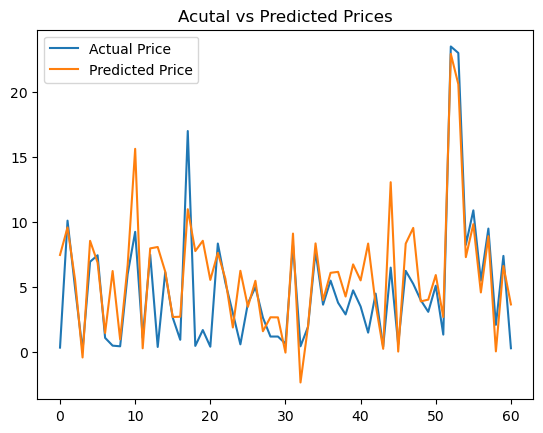

In [11]:
# 1.Actual vs predicted prices
plt.plot(y_test.values,label = 'Actual Price')
plt.plot(y_pred, label = "Predicted Price")
plt.legend()
plt.title("Acutal vs Predicted Prices")
plt.show()

In [12]:
#sample prediction
sample = x_test.iloc[0:1]
predicted_price = model.predict(sample)

print("\nPredicted Price for Sample Car:", predicted_price[0])


Predicted Price for Sample Car: 7.473270505399569


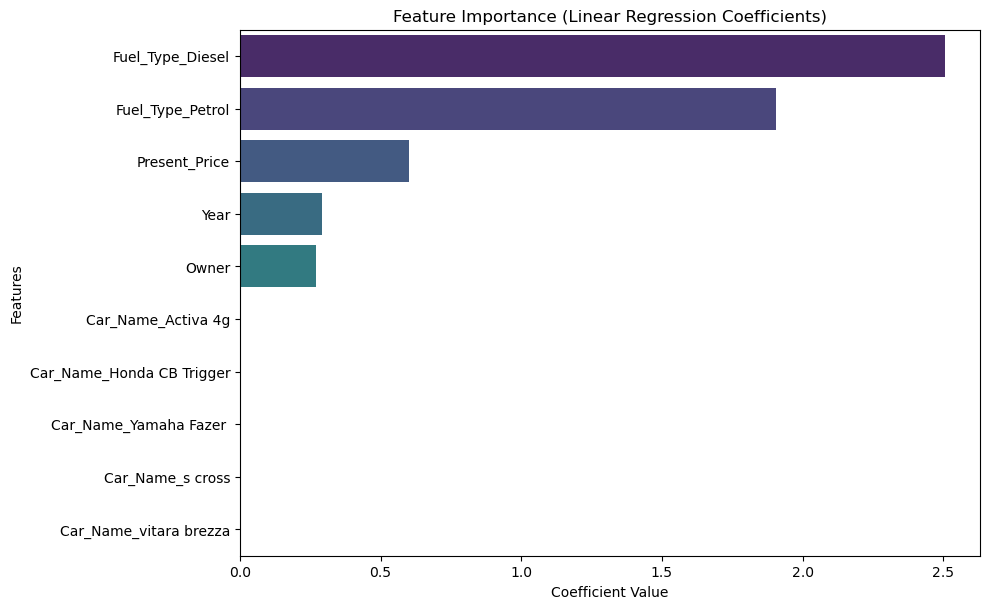

In [13]:
# 2.Feature Importance / Coefficient Analysis
coef = pd.Series(model.coef_, index=x.columns)
coef = coef.sort_values(ascending=False)
top_coef = coef.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_coef.values, y=top_coef.index, palette="viridis")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

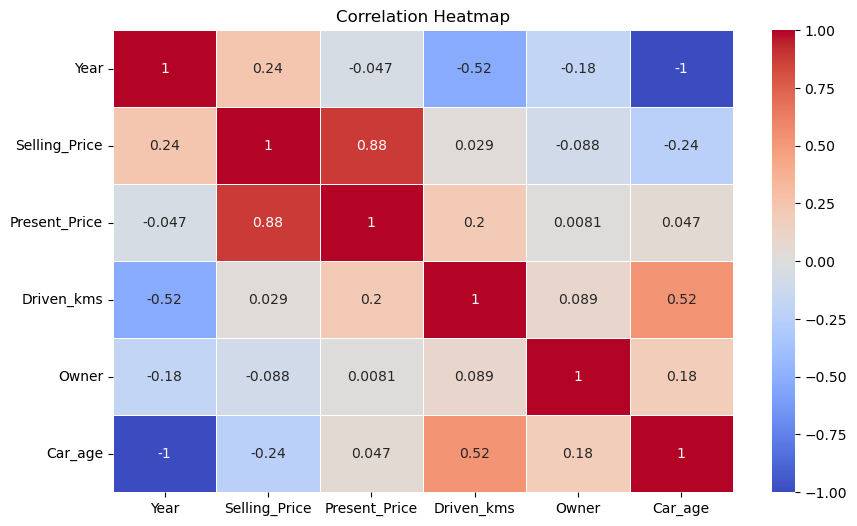

In [14]:
# 3.Correlation Heatmap
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("\nINSIGHTS:")
print("1. The Linear Regression model predicted car prices with a Mean Absolute Error (MAE) of 2.04.")
print("2. This means predictions were off by around 2 lakhs on average.")
print("3. The Mean Squared Error (MSE) was 9.22, showing some larger prediction errors.")
print("4. The R2 Score was 0.60, meaning the model explains nearly 60% of price variation.")
print("5. The Actual vs Predicted graph shows predicted prices generally follow actual prices.")
print("6. Some differences exist, so accuracy can be improved further.")
print("7. The predicted price for the sample car was 7.47 lakhs.")
print("8. Features like car age, present price, fuel type, driven kms, and transmission affect price.")
print("9. Linear Regression gives moderate accuracy for this dataset.")
print("10. Advanced models like Random Forest can improve prediction performance.")


INSIGHTS:
1. The Linear Regression model predicted car prices with a Mean Absolute Error (MAE) of 2.04.
2. This means predictions were off by around 2 lakhs on average.
3. The Mean Squared Error (MSE) was 9.22, showing some larger prediction errors.
4. The R2 Score was 0.60, meaning the model explains nearly 60% of price variation.
5. The Actual vs Predicted graph shows predicted prices generally follow actual prices.
6. Some differences exist, so accuracy can be improved further.
7. The predicted price for the sample car was 7.47 lakhs.
8. Features like car age, present price, fuel type, driven kms, and transmission affect price.
9. Linear Regression gives moderate accuracy for this dataset.
10. Advanced models like Random Forest can improve prediction performance.
